# P2 — Analisis y Visualizacion · TSP con Algoritmos Genéticos
**Secciones c, d, e**



### Estructura directorio
```
proyecto/
├── dataset/
│   └── cities_100_101112.csv
├── P1_GA_engine.py
├── p2_analysis.py
└── p2_notebook.ipynb   ← este archivo
```

---
## Carga el CSV, corre el AG de P1 y genera figuras automáticamente.

[P2] Cargando ciudades desde: dataset/cities_100_456.csv
[P2] 100 ciudades cargadas correctamente.
[P2] Ejecutando AG  |  n_pop=100  n_gen=300  p_cx=0.9  p_mut=0.05
[P2] AG finalizado  |  Mejor fitness: 1,697.38
[P2] Baseline NN    |  Fitness NN: 1,866.47
[P2] Generando dashboard completo...
  [guardado] p2_dashboard.png


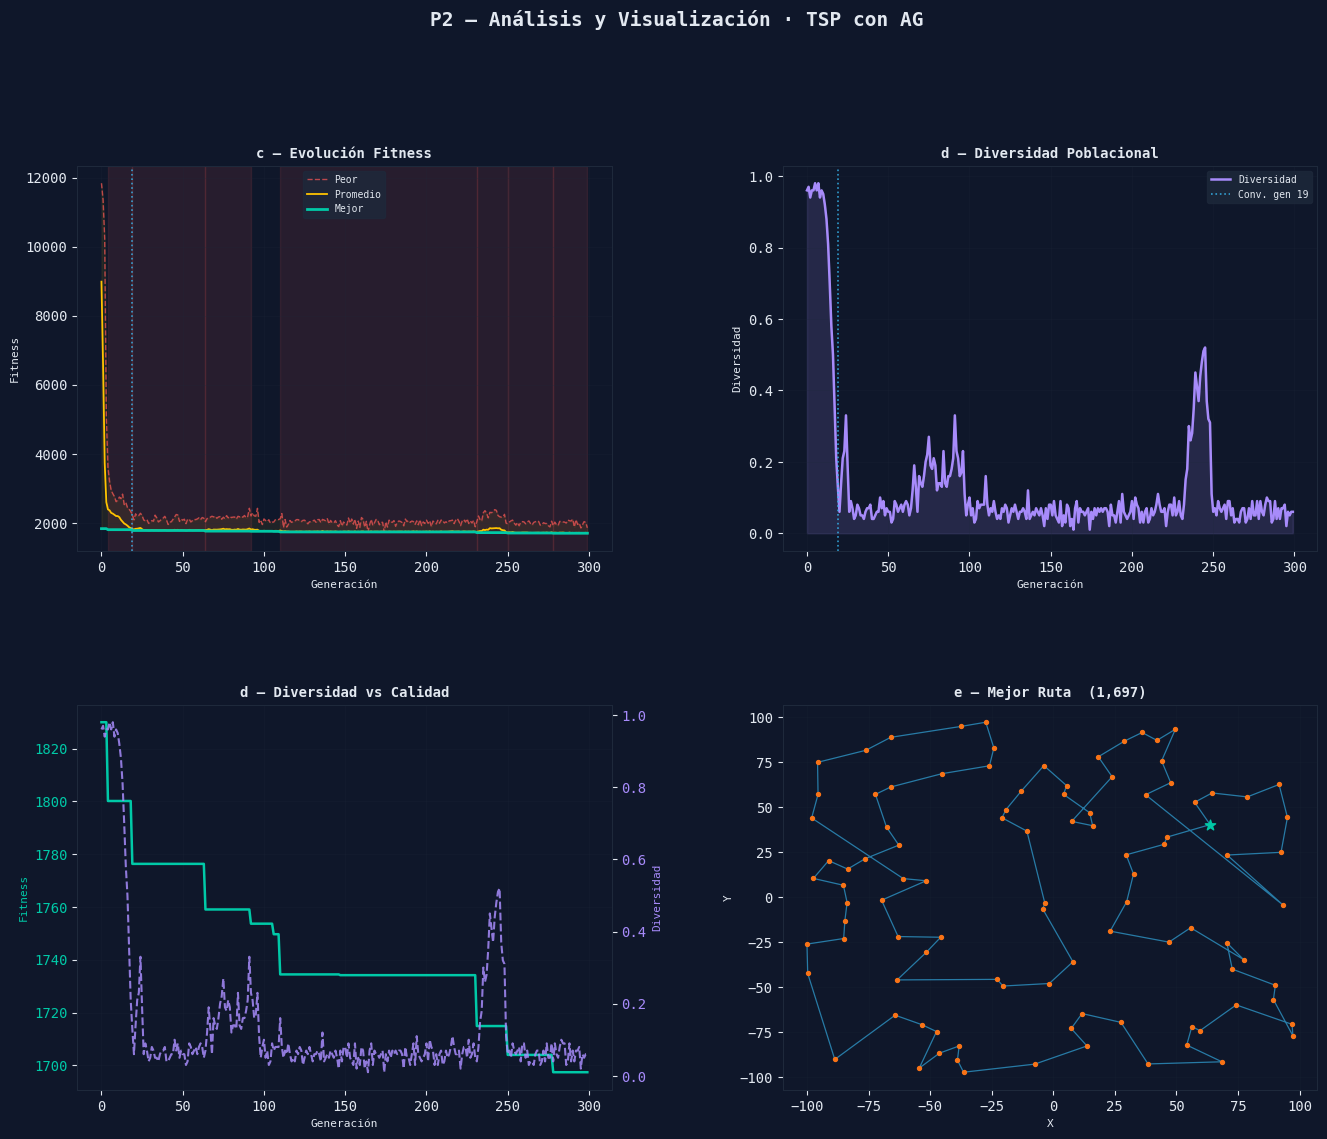

[P2] Figura c — Evolución del Fitness...
  [guardado] p2_fitness_evolution.png


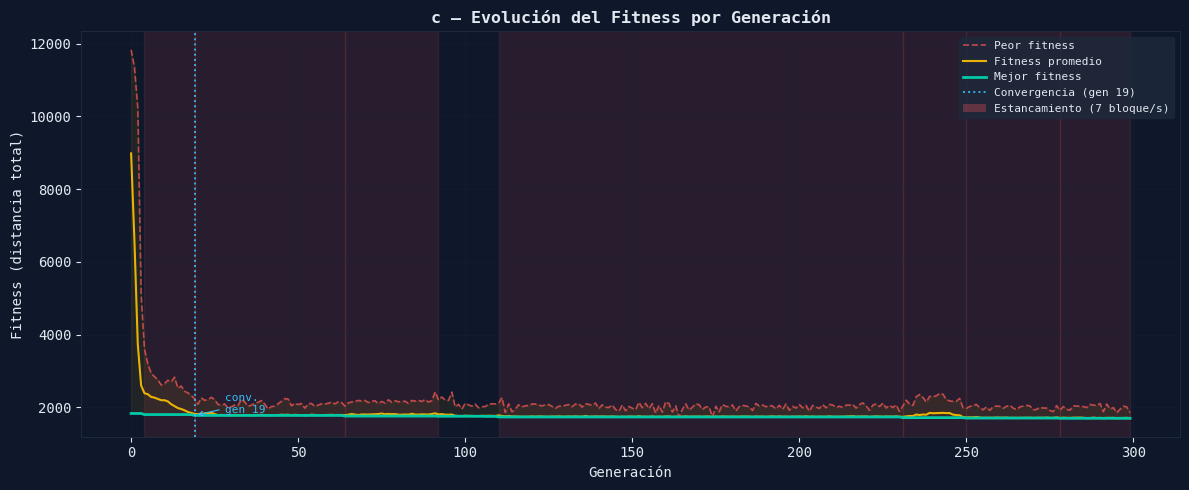

[P2] Figura d — Diversidad...
  [guardado] p2_diversity.png


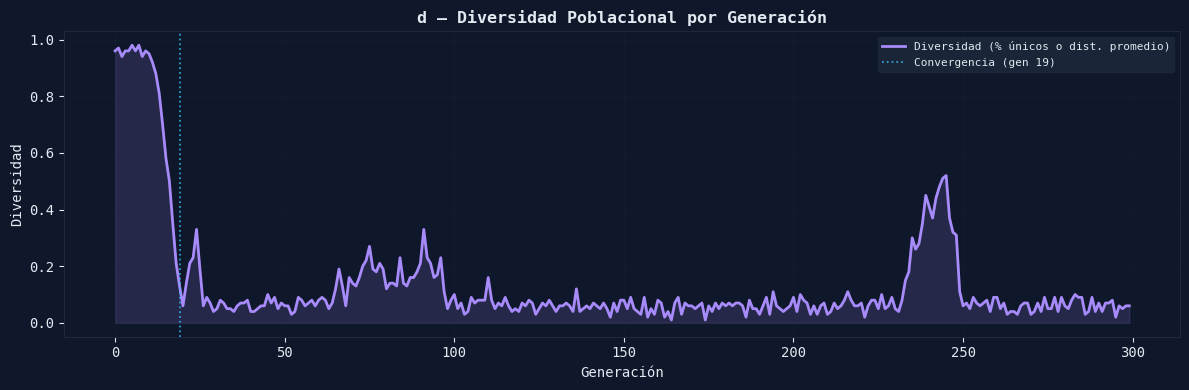

[P2] Figura d — Diversidad vs Fitness...
  [guardado] p2_diversity_vs_fitness.png


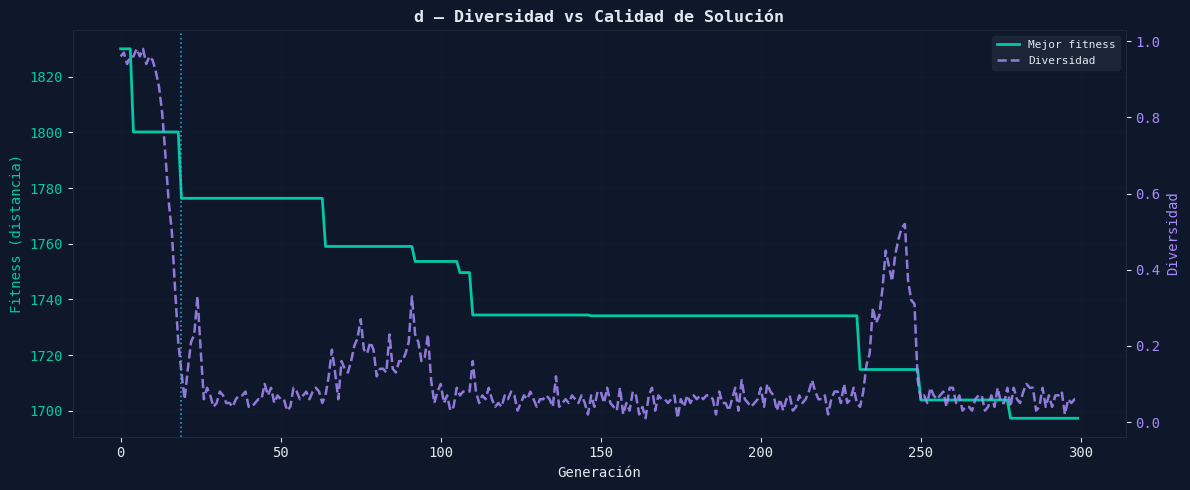

[P2] Figura e — Mapa de ruta...
  [guardado] p2_route_map.png


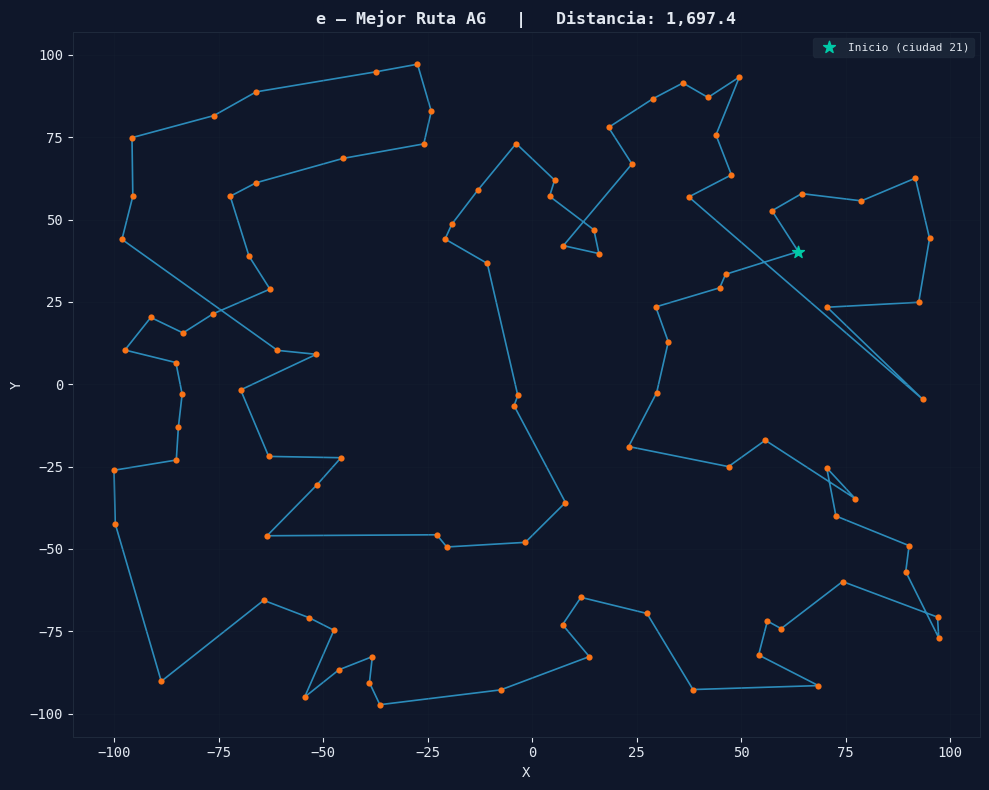

[P2] Tabla e — Comparación AG vs NN...
  [guardado] p2_comparison_table.png


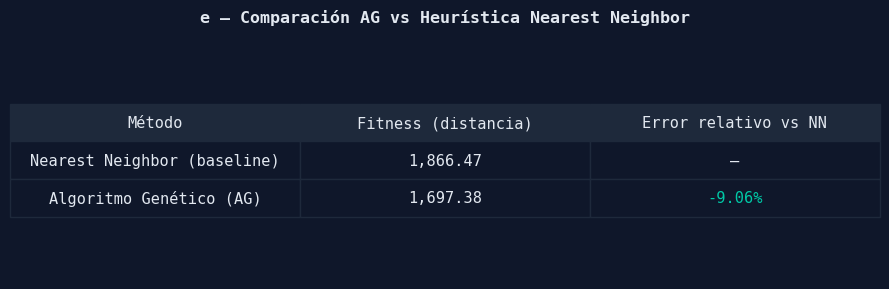


  RESUMEN P2 — Análisis de Calidad
  Fitness AG          :     1,697.38
  Fitness NN baseline :     1,866.47
  Error relativo      :       -9.06 %
  Convergencia en gen : 19
  Bloques estancado   : 7
  % únicos (final)    : 5.0 %



In [1]:
%matplotlib inline
from p2_analysis import run_p2

summary = run_p2(
    csv_path    = "dataset/cities_100_456.csv",
    n_pop       = 100,
    n_gen       = 300,
    p_crossover = 0.9,
    p_mutation  = 0.05,
    seed        = 42,
)

In [2]:
# Ver el resumen de métricas finales
print(summary)

{'ag_fitness': 1697.3818381118072, 'nn_fitness': 1866.4673577181757, 'relative_error': -9.059120102324304, 'pct_unique_final': 5.0, 'convergence_gen': 19, 'stagnation_blocks': 7}


---
## Generar figuras individuales.

In [3]:
%matplotlib inline

# Paso 1: importar P1 y P2
from P1_GA_engine import (
    load_cities_from_csv,
    run_ga,
    build_distance_matrix,
    nearest_neighbor_baseline,
)
from p2_analysis import P2Analyzer

# Paso 2: cargar ciudades
cities = load_cities_from_csv("dataset/cities_100_101112.csv")
print(f"Ciudades cargadas: {len(cities)}")
print(f"Ejemplo (primeras 3): {cities[:3]}")

Ciudades cargadas: 100
Ejemplo (primeras 3): [(-26.1, -3.3), (17.1, -43.3), (-70.7, -42.0)]


In [4]:
# Paso 3: configurar y correr el AG de P1
config = {
    "cities":      cities,
    "n_pop":       100,
    "n_gen":       300,
    "p_crossover": 0.9,
    "p_mutation":  0.05,
    "seed":        42,
}

results = run_ga(config)

print(f"Mejor fitness encontrado : {results['best_fitness']:,.2f}")
print(f"Generaciones registradas : {len(results['fitness_history'])}")
print(f"Tamaño población final   : {len(results['final_population'])}")

Mejor fitness encontrado : 1,793.42
Generaciones registradas : 300
Tamaño población final   : 100


In [5]:
# Paso 4: calcular baseline NN desde P1
distance_matrix      = build_distance_matrix(cities)
nn_route, nn_fitness = nearest_neighbor_baseline(distance_matrix, start=0)

print(f"Fitness Nearest Neighbor : {nn_fitness:,.2f}")
print(f"Fitness AG               : {results['best_fitness']:,.2f}")

Fitness Nearest Neighbor : 1,871.26
Fitness AG               : 1,793.42


In [6]:
# Paso 5: crear el analizador P2
analyzer = P2Analyzer(
    results      = results,
    cities       = cities,
    nn_result    = (nn_route, nn_fitness),
    save_figures = True,
    fig_prefix   = "p2",
)

---
## Figuras individuales

  [guardado] p2_dashboard.png


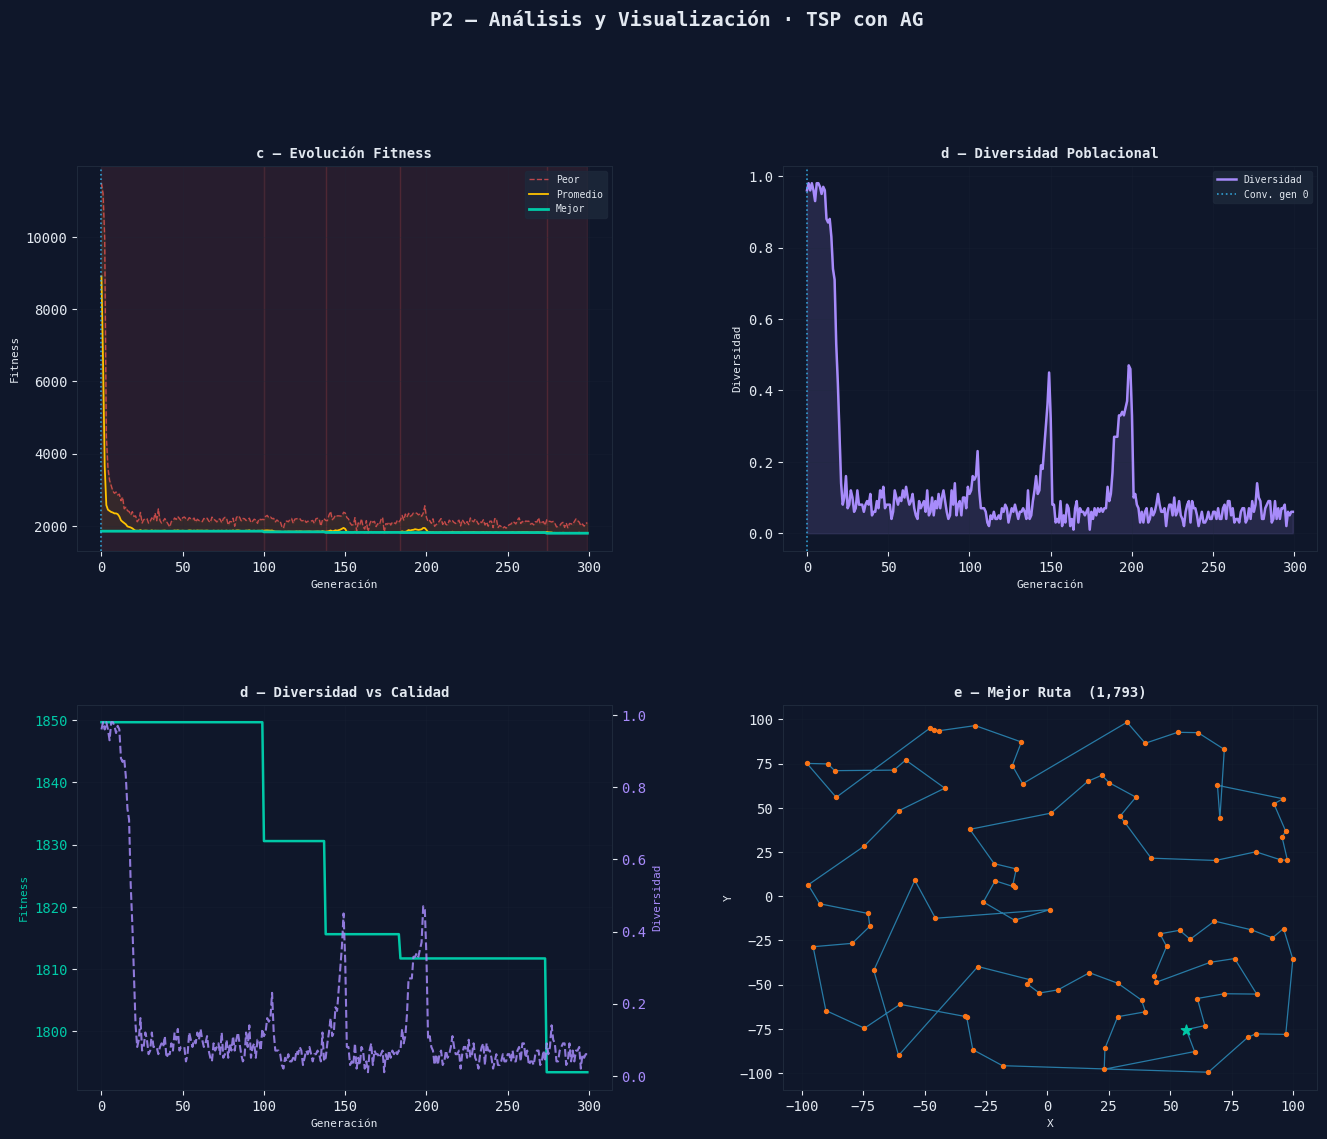

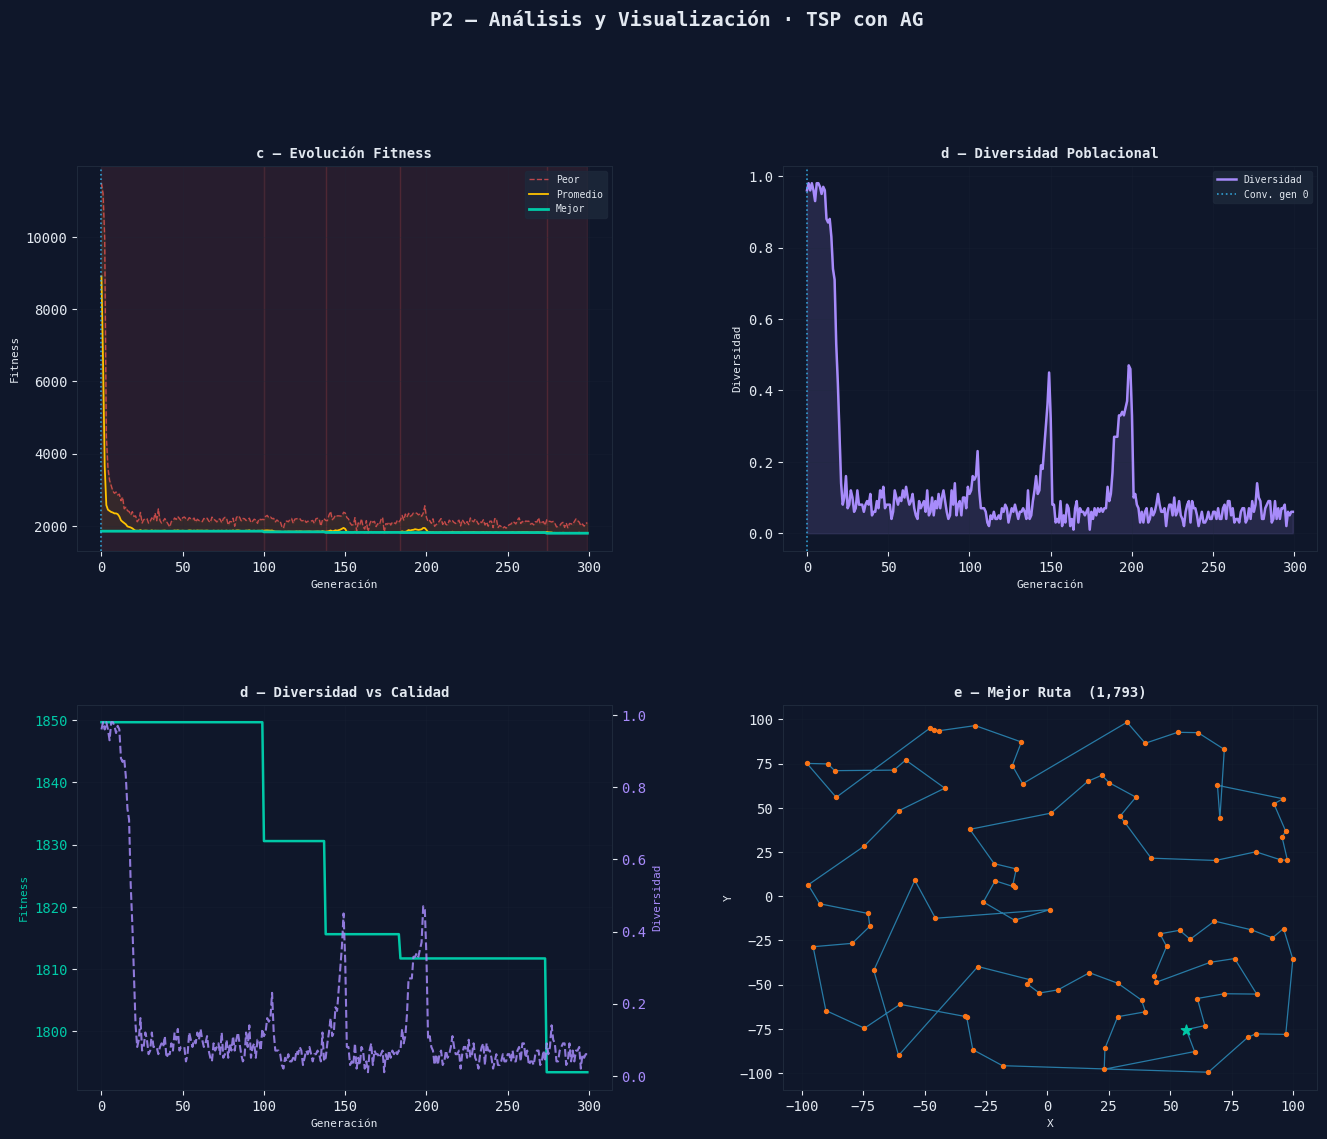

In [7]:
# Dashboard general (4 paneles)
analyzer.plot_dashboard()

  [guardado] p2_fitness_evolution.png


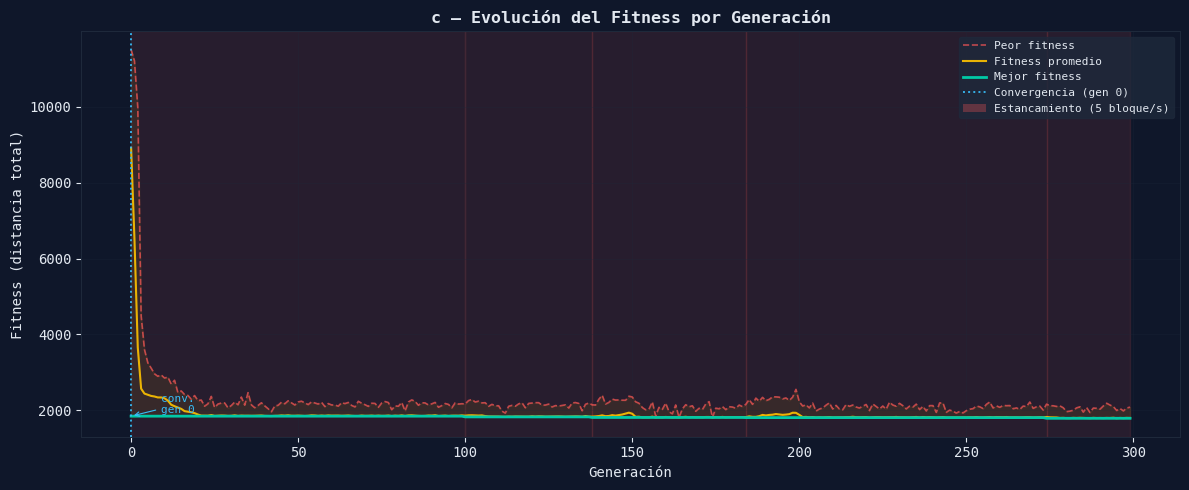

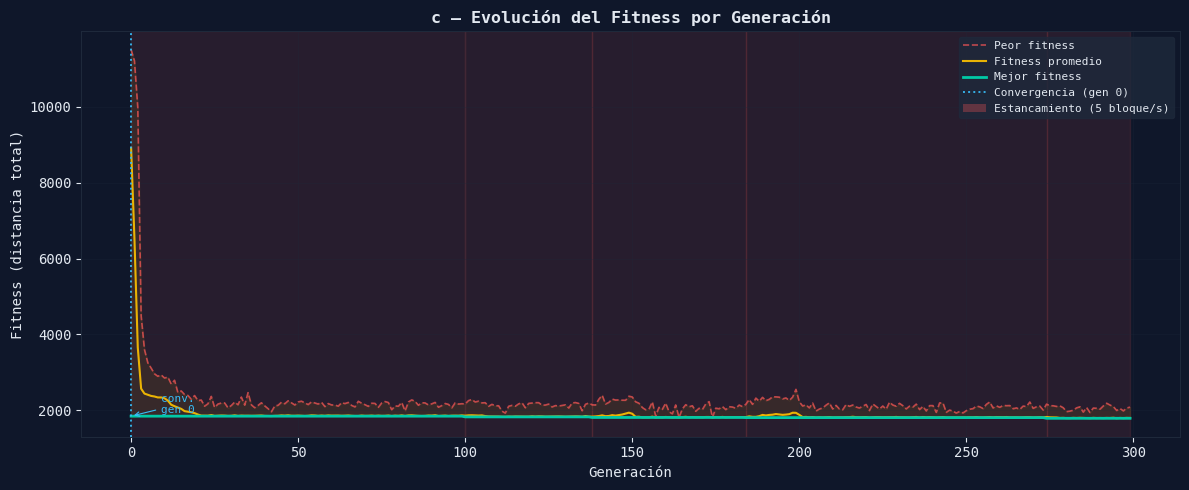

In [8]:
# c — Evolución del fitness
analyzer.plot_fitness_evolution()

  [guardado] p2_diversity.png


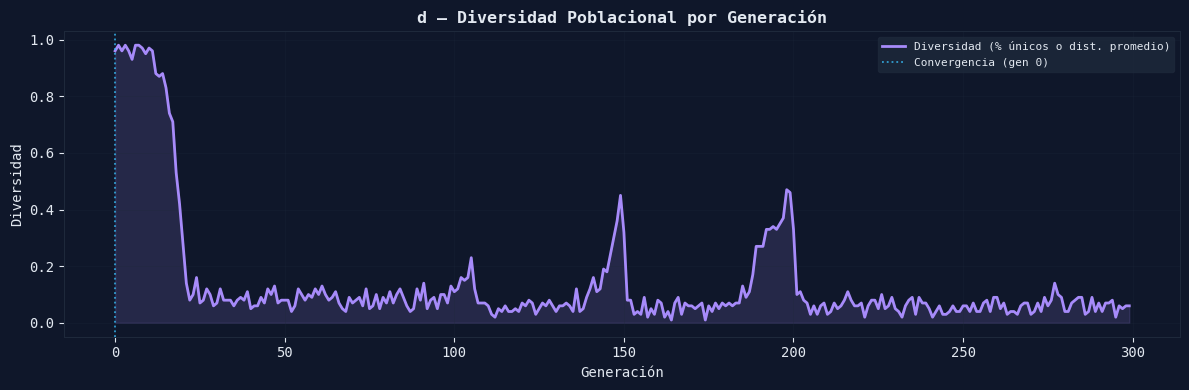

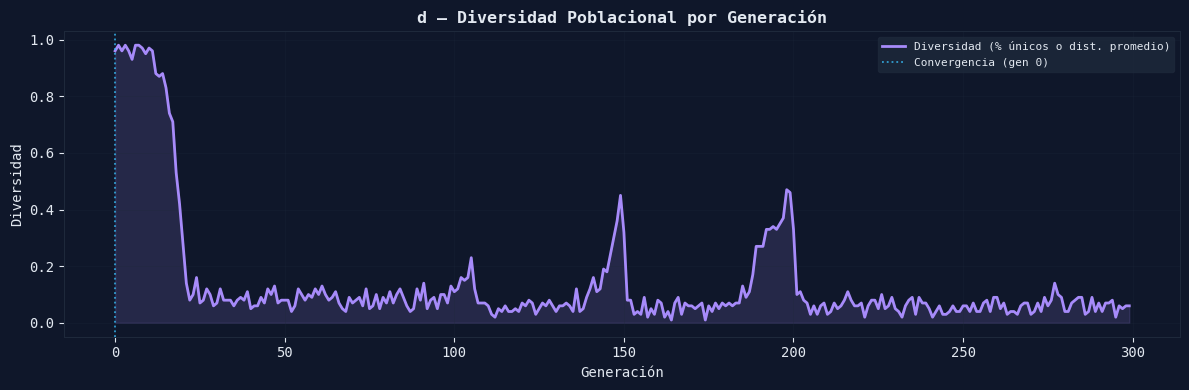

In [9]:
# d — Diversidad poblacional
analyzer.plot_diversity()

  [guardado] p2_diversity_vs_fitness.png


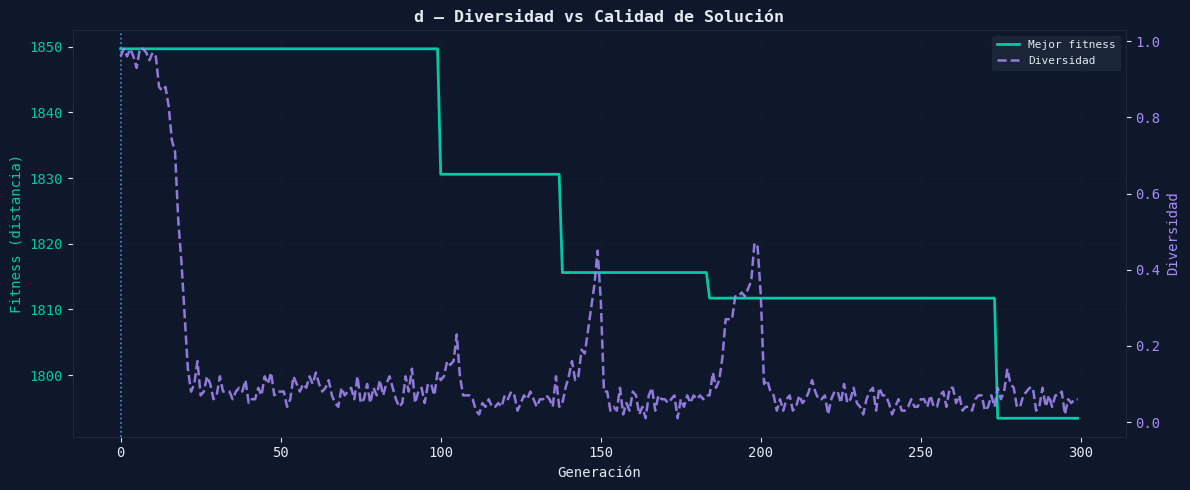

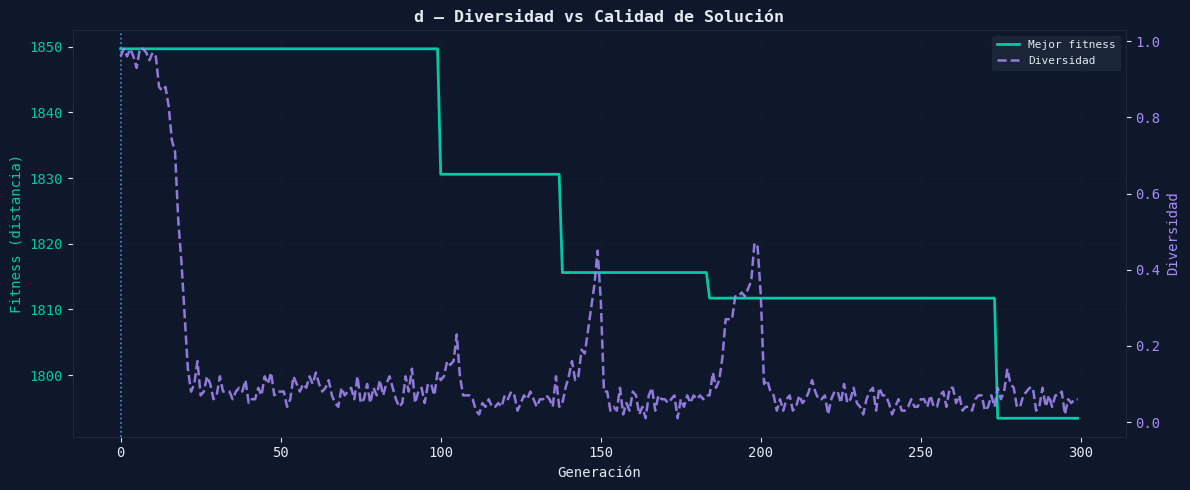

In [10]:
# d — Diversidad vs Calidad (doble eje)
analyzer.plot_diversity_vs_fitness()

  [guardado] p2_route_map.png


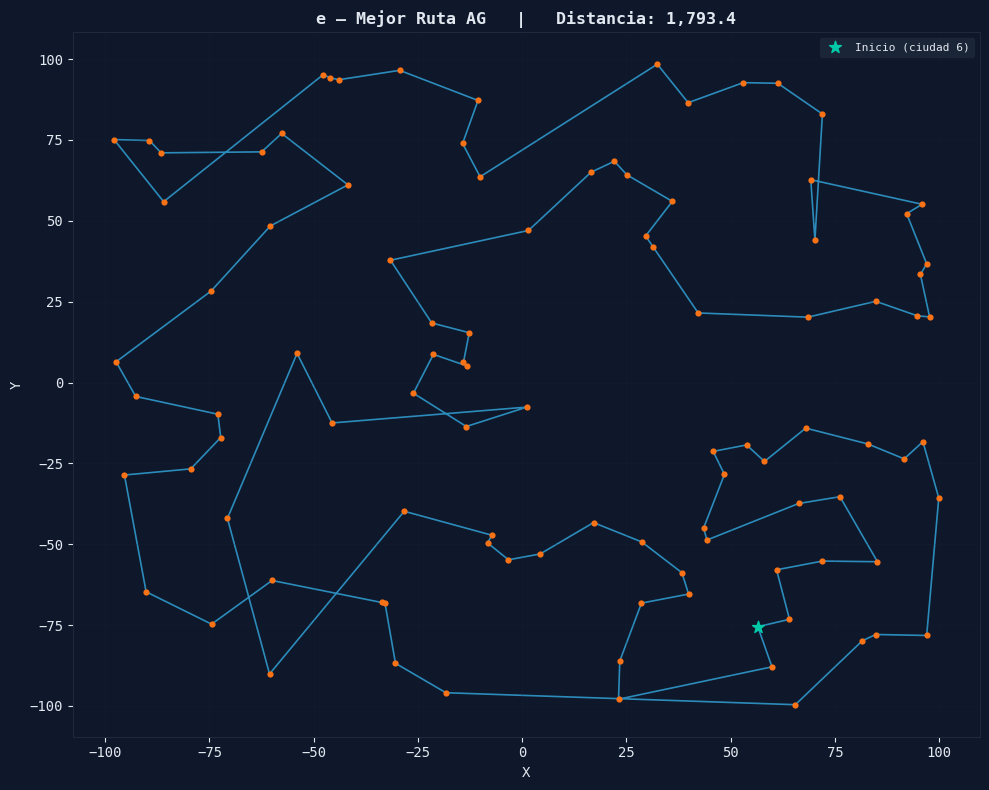

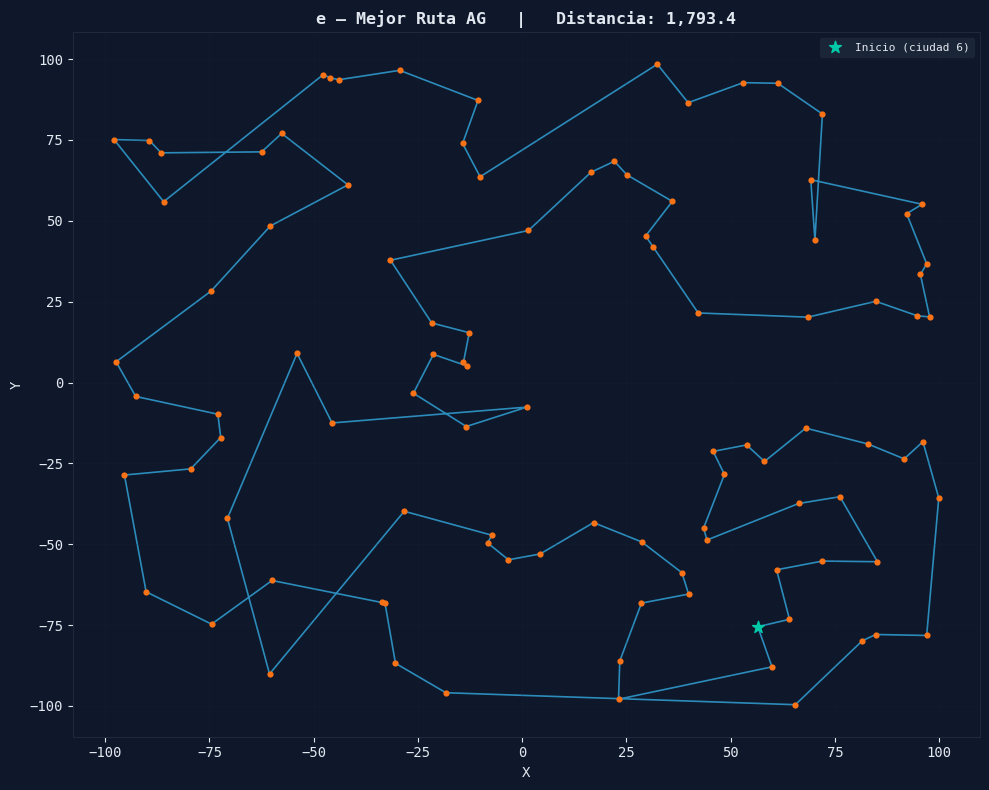

In [11]:
# e — Mapa de la mejor ruta
analyzer.plot_route_map()

  [guardado] p2_comparison_table.png


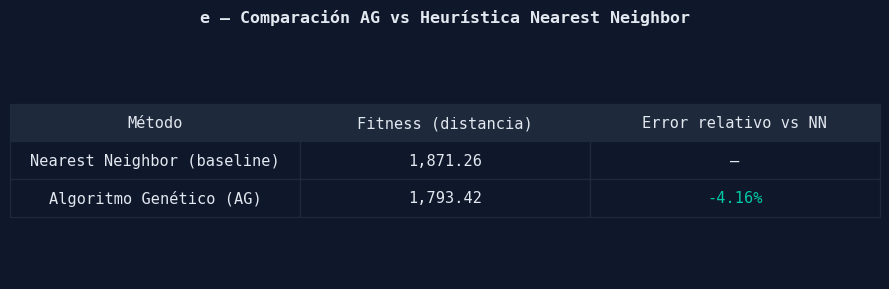


  RESUMEN P2 — Análisis de Calidad
  Fitness AG          :     1,793.42
  Fitness NN baseline :     1,871.26
  Error relativo      :       -4.16 %
  Convergencia en gen : 0
  Bloques estancado   : 5
  % únicos (final)    : 5.0 %

{'ag_fitness': 1793.4214543420735, 'nn_fitness': 1871.2644006289838, 'relative_error': -4.15991167580301, 'pct_unique_final': 5.0, 'convergence_gen': 0, 'stagnation_blocks': 5}


In [12]:
# e — Tabla comparativa AG vs NN + error relativo
summary = analyzer.plot_comparison_table()
print(summary)

---
## Modo simulación (trabajar sin datos de P1)

[P2] Calculando baseline nearest-neighbor...
[P2] Generando dashboard completo...


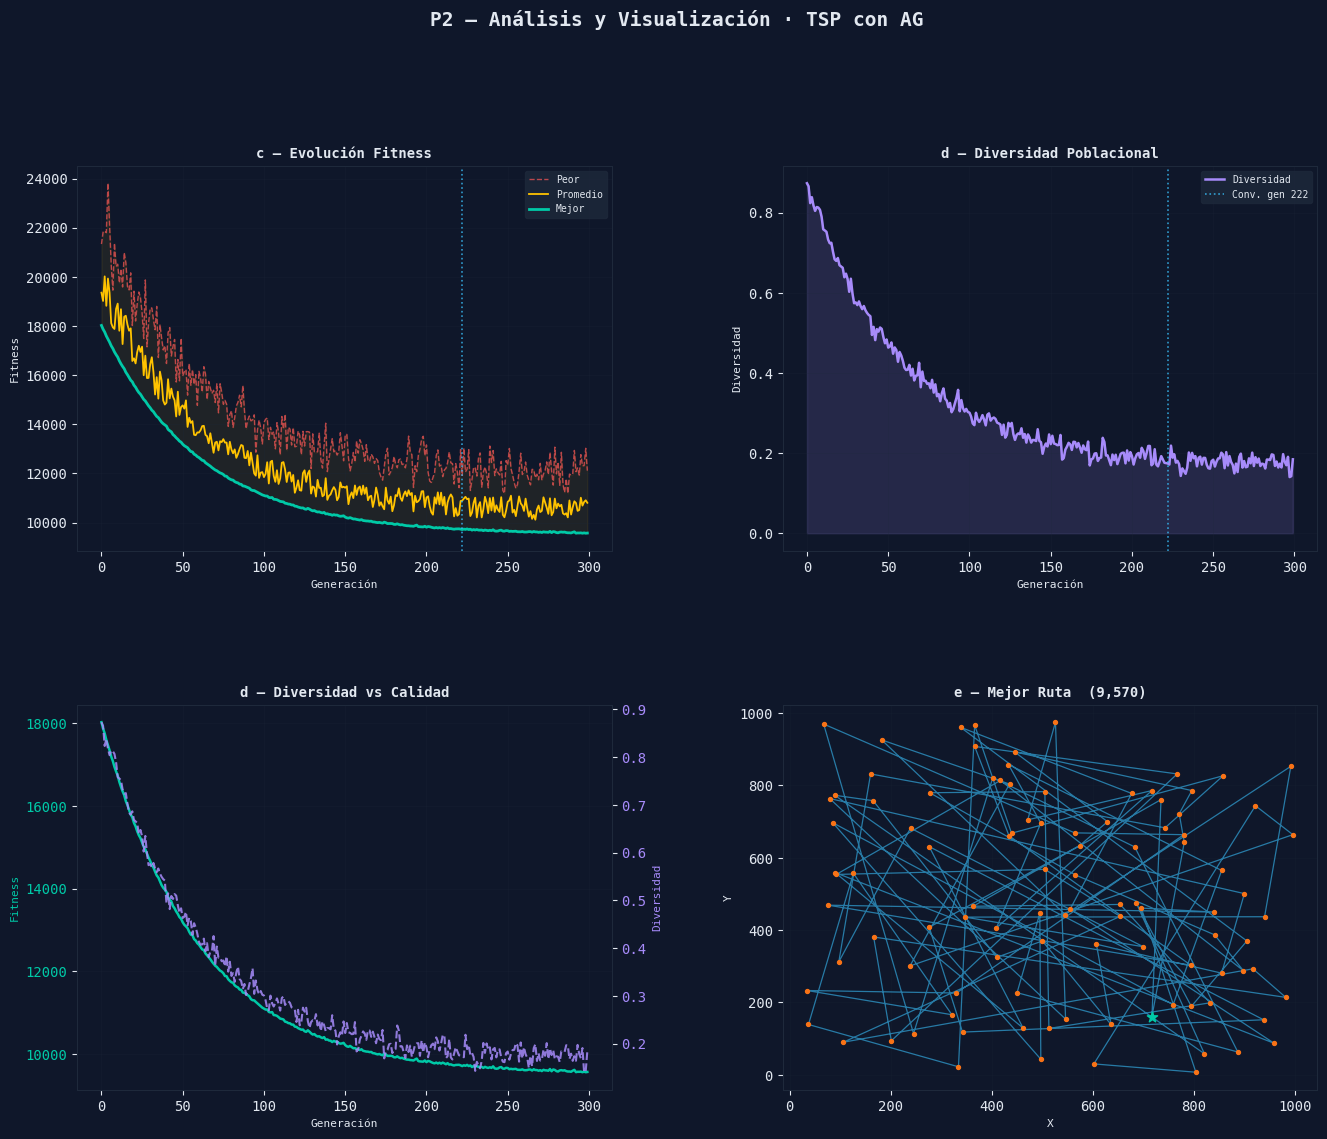

[P2] Figura c — Evolución del Fitness...


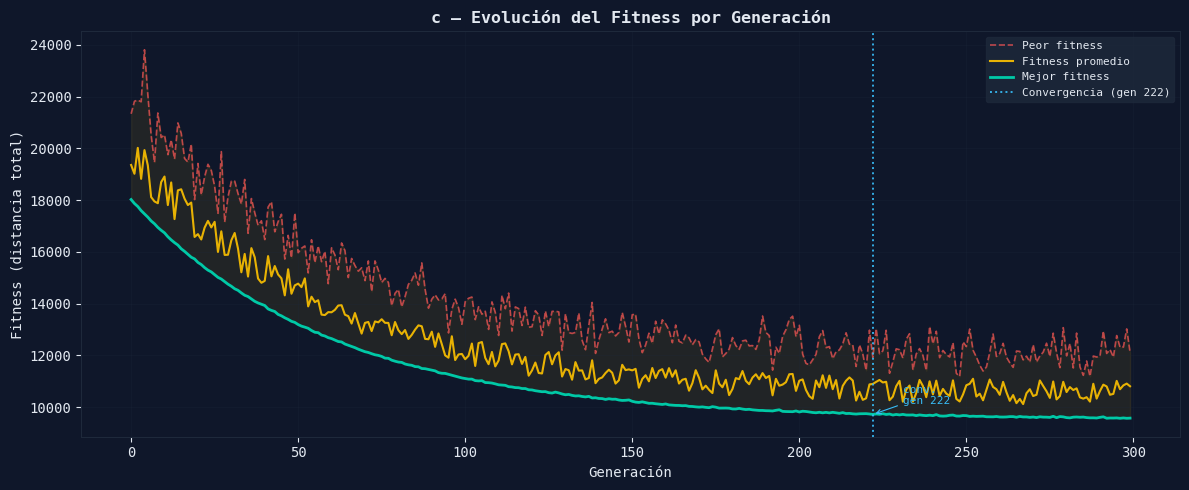

[P2] Figura d — Diversidad...


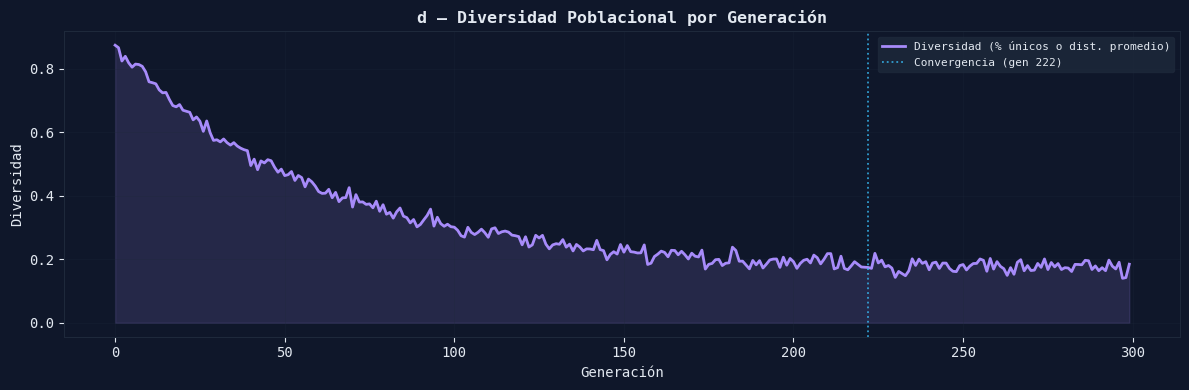

[P2] Figura d — Diversidad vs Fitness...


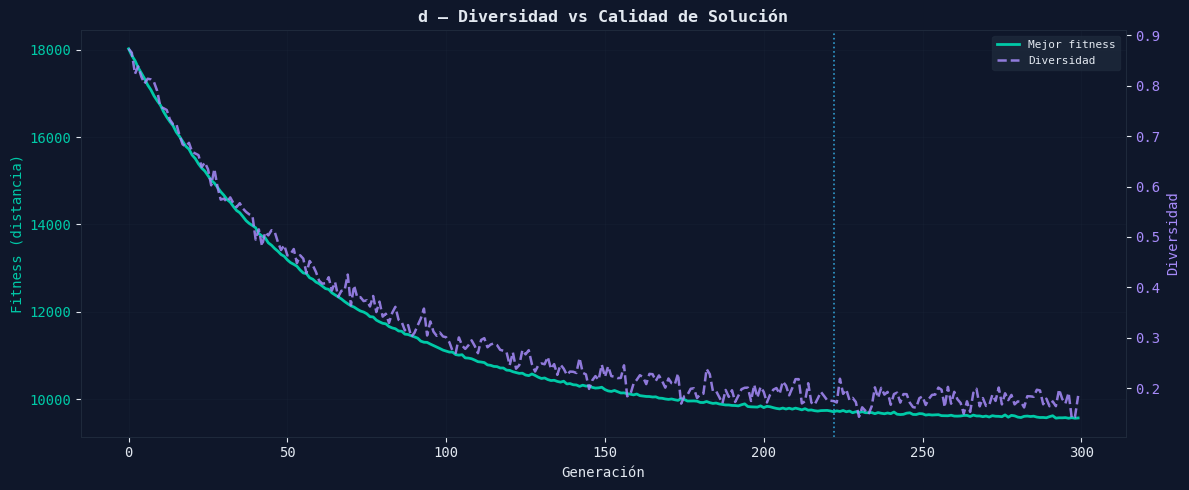

[P2] Figura e — Mapa de ruta...


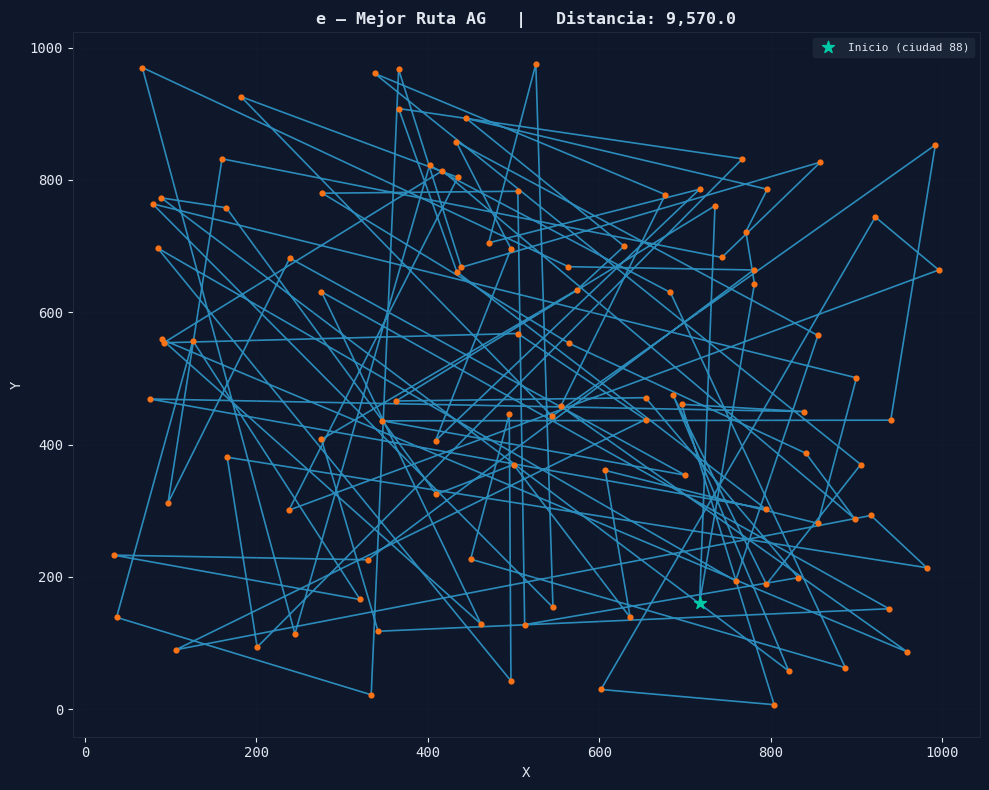

[P2] Tabla e — Comparación AG vs NN...


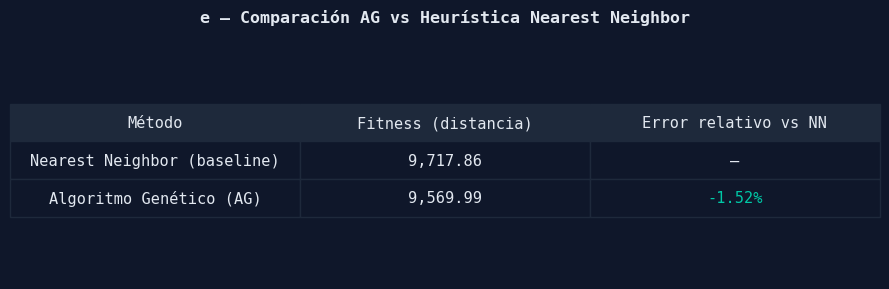


  RESUMEN P2 — Análisis de Calidad
  Fitness AG          :     9,569.99
  Fitness NN baseline :     9,717.86
  Error relativo      :       -1.52 %
  Convergencia en gen : 222
  Bloques estancado   : 0
  % únicos (final)    : 100.0 %



{'ag_fitness': 9569.994102426663,
 'nn_fitness': np.float64(9717.85842682907),
 'relative_error': np.float64(-1.5215731481967667),
 'pct_unique_final': 100.0,
 'convergence_gen': 222,
 'stagnation_blocks': 0}

In [13]:
from p2_analysis import generate_mock_results, P2Analyzer

mock = generate_mock_results(n_cities=101, n_gen=300, n_pop=100)

analyzer_mock = P2Analyzer(
    results      = mock,
    cities       = mock["_cities_mock"],
    save_figures = False,
)

analyzer_mock.run_all()